In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from torch.utils.data import TensorDataset, DataLoader

Importing the test dataset csv

In [2]:
train_df = pd.read_csv("mnist_train.csv")

We have 60k testing data

In [3]:
train_df.shape

(60000, 785)

Splitting the features and normalizing the data

In [10]:
x = train_df.iloc[:, 1:].values
x = x/255.0
y = train_df.iloc[:, 0].values

In [12]:
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

creating the dataloaders

In [16]:
train_ds = TensorDataset(X_train_t, y_train_t)

val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

val_loader = DataLoader(val_ds, batch_size=64)

making the ANN here

In [19]:
class DigitANN(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.network(x)

initializing model

In [20]:
model = DigitANN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
epochs = 10

for epoch in range(epochs):
    model.train()
    curr_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        
        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        curr_loss+=loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {curr_loss/len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 0.3449
Epoch 2/10, Loss: 0.1302
Epoch 3/10, Loss: 0.0851
Epoch 4/10, Loss: 0.0646
Epoch 5/10, Loss: 0.0506
Epoch 6/10, Loss: 0.0391
Epoch 7/10, Loss: 0.0317
Epoch 8/10, Loss: 0.0292
Epoch 9/10, Loss: 0.0218
Epoch 10/10, Loss: 0.0216


let's evaluate the model

In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)

        _, predicted = torch.max(outputs, dim=1)

        total+=y_batch.size(0)

        correct+=(predicted==y_batch).sum().item()

accuracy = 100*correct/total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 97.35%


97.35% is great, let us test with single digits and see if the models tells it correctly or not

Predicted: 0
Actual: 0
tensor([[1.0000e+00, 8.9249e-12, 3.9507e-07, 1.1796e-12, 2.8432e-11, 2.0443e-11,
         1.6812e-08, 1.7316e-11, 3.9938e-12, 1.3621e-09]])


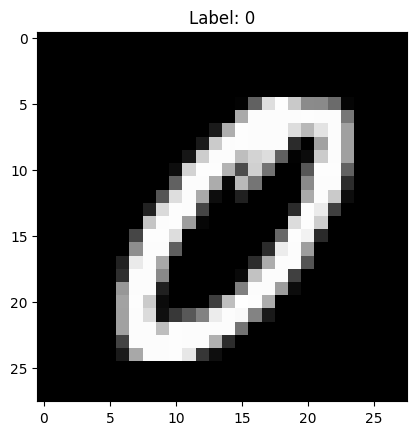

In [43]:
idx = 9273

sample = X_val_t[idx]

with torch.no_grad():
    output=model(sample.unsqueeze(0))

    prediction = torch.argmax(output, dim=1)

print("Predicted:", prediction.item())
print("Actual:", y_val[idx])

import torch.nn.functional as F

with torch.no_grad():
    logits = model(sample.unsqueeze(0))
    probs = F.softmax(logits, dim=1)

print(f"{probs}")

import matplotlib.pyplot as plt

image = X_val[idx].reshape(28, 28)

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    f"Label: {y_val[idx]}"
)

plt.show()